<a href="https://colab.research.google.com/github/modouseck/Python-Machine-Learning/blob/master/check_pointvisualisation_%2C_web_scraping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
import pandas as pd

# Charger les données
df = pd.read_csv('/content/Africa_climate_change.csv')

# Afficher les premières lignes
df.head()


,DATE,PRCP,TAVG,TMAX,TMIN,COUNTRY
0,19800101 000000,NaN,54.0,61.0,43.0,Tunisia
1,19800101 000000,NaN,49.0,55.0,41.0,Tunisia
2,19800101 000000,0.0,72.0,86.0,59.0,Cameroon
3,19800101 000000,NaN,50.0,55.0,43.0,Tunisia
4,19800101 000000,NaN,75.0,91.0,NaN,Cameroon


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 464815 entries, 0 to 464814
Data columns (total 6 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   DATE     464815 non-null  object 
 1   PRCP     177575 non-null  float64
 2   TAVG     458439 non-null  float64
 3   TMAX     363901 non-null  float64
 4   TMIN     332757 non-null  float64
 5   COUNTRY  464815 non-null  object 
dtypes: float64(4), object(2)
memory usage: 21.3+ MB


In [52]:
df.describe()

,PRCP,TAVG,TMAX,TMIN
count,177575.000000,458439.000000,363901.000000,332757.000000
mean,0.120941,77.029838,88.713969,65.548262
std,0.486208,11.523634,13.042631,11.536547
min,0.000000,-49.000000,41.000000,12.000000
25%,0.000000,70.000000,81.000000,58.000000
50%,0.000000,80.000000,90.000000,68.000000
75%,0.010000,85.000000,99.000000,74.000000
max,19.690000,110.000000,123.000000,97.000000


In [24]:
df['TAVG'].value_counts()

,count
TAVG,
83.0,5781
80.0,5724
81.0,5530
82.0,5078
85.0,4411
...,...
39.0,3
38.0,2
108.0,1


In [45]:
# Nettoyage : supprimer les valeurs manquantes pour la température moyenne
df_clean = df.dropna(subset=["TAVG", "COUNTRY"])

# Extraire l'année de la colonne DATE
df_clean["year"] = df_clean["DATE"].astype(str).str[:4].astype(int)

# Renommer les colonnes pour simplifier
df_clean.rename(columns={"TAVG": "temperature", "COUNTRY": "country"}, inplace=True)

# Filtrer pour la Tunisie et le Cameroun entre 1980 et 2005
df_zoom = df_clean[
    (df_clean["country"].isin(["Tunisia", "Cameroon"])) &
    (df_clean["year"] >= 1980) &
    (df_clean["year"] <= 2005)
]

# Vérification
df_zoom.head()


<ipython-input-45-96a6be7c4598>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["year"] = df_clean["DATE"].astype(str).str[:4].astype(int)
<ipython-input-45-96a6be7c4598>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean.rename(columns={"TAVG": "temperature", "COUNTRY": "country"}, inplace=True)


,DATE,PRCP,temperature,TMAX,TMIN,country,year
0,19800101 000000,NaN,54.0,61.0,43.0,Tunisia,1980
1,19800101 000000,NaN,49.0,55.0,41.0,Tunisia,1980
2,19800101 000000,0.0,72.0,86.0,59.0,Cameroon,1980
3,19800101 000000,NaN,50.0,55.0,43.0,Tunisia,1980
4,19800101 000000,NaN,75.0,91.0,NaN,Cameroon,1980


In [5]:
print(df.columns)

Index(['DATE', 'PRCP', 'TAVG', 'TMAX', 'TMIN', 'COUNTRY'], dtype='object')


In [46]:
# Nettoyage : supprimer les valeurs manquantes pour la température moyenne
df_clean = df.dropna(subset=["TAVG", "COUNTRY"])

# Extraire l'année de la colonne DATE
df_clean["year"] = df_clean["DATE"].astype(str).str[:4].astype(int)

# Renommer les colonnes pour simplifier
df_clean.rename(columns={"TAVG": "temperature", "COUNTRY": "country"}, inplace=True)

# Filtrer pour la Tunisie et le Cameroun entre 1980 et 2005
df_zoom = df_clean[
    (df_clean["country"].isin(["Tunisia", "Cameroon"])) &
    (df_clean["year"] >= 1980) &
    (df_clean["year"] <= 2005)
]

# Vérification
df_zoom.head()


<ipython-input-46-96a6be7c4598>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["year"] = df_clean["DATE"].astype(str).str[:4].astype(int)
<ipython-input-46-96a6be7c4598>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean.rename(columns={"TAVG": "temperature", "COUNTRY": "country"}, inplace=True)


,DATE,PRCP,temperature,TMAX,TMIN,country,year
0,19800101 000000,NaN,54.0,61.0,43.0,Tunisia,1980
1,19800101 000000,NaN,49.0,55.0,41.0,Tunisia,1980
2,19800101 000000,0.0,72.0,86.0,59.0,Cameroon,1980
3,19800101 000000,NaN,50.0,55.0,43.0,Tunisia,1980
4,19800101 000000,NaN,75.0,91.0,NaN,Cameroon,1980


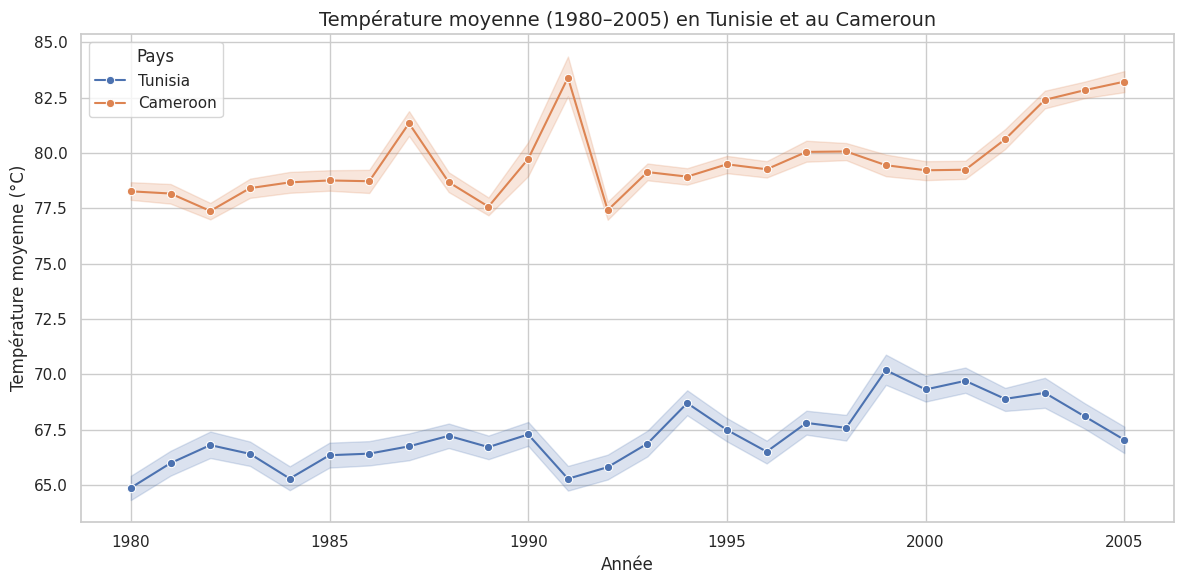

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Définir le style
sns.set(style="whitegrid")

# Tracer le graphique
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_zoom, x='year', y='temperature', hue='country', marker='o')

# Personnalisation
plt.title("Température moyenne (1980–2005) en Tunisie et au Cameroun", fontsize=14)
plt.xlabel("Année", fontsize=12)
plt.ylabel("Température moyenne (°C)", fontsize=12)
plt.legend(title="Pays")
plt.tight_layout()
plt.show()
